# Category-level correlation analysis
20260514

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.stats.multitest as mt
import pingouin as pg
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

project_root = os.path.abspath("/home/jovyan/work")

if project_root not in sys.path:
    sys.path.append(project_root)

from funcs import core, viz

In [2]:
path_data = project_root + "/data/raw"
df_bdi = pd.read_csv(path_data + "/BDI_score.csv", header=0)
bdi_col_name = df_bdi.columns[1]

In [14]:
# Load and modify dataframe

df_amy_raw = pd.read_csv(path_data + "/Amy_dissimilarity.csv", header=None)

word1_row = df_amy_raw.iloc[0].astype(str)
word2_row = df_amy_raw.iloc[1].astype(str)

new_columns = ['Sub']
for i in range(1, len(df_amy_raw.columns)):
    col_name = f"{word1_row[i]}_{word2_row[i]}"
    new_columns.append(col_name)

df_amy_data = df_amy_raw.iloc[2:].copy()

df_amy_data.columns = new_columns
df_amy_data = df_amy_data.apply(pd.to_numeric, errors='coerce')

df_merged = pd.merge(df_amy_data, df_bdi, on="Sub", how="inner")

In [15]:
df_merged

,Sub,brown_anger,orange_anxiety,red_yellow,black_blue,green_calm,red_pink,envy_joy,fear_anger,pink_green,...,blue_anxiety,fear_happiness,purple_confidence,disgust_defeated,calm_happiness,orange_pink,green_disgust,brown_joy,anxiety_boredom,BDI
0,0,6,2,2,1,0,0,7,0,2,...,2,7,2,5,2,3,0,4,5,0
1,1,6,6,3,6,6,6,7,6,3,...,7,7,6,1,6,4,6,6,1,0
2,2,7,7,0,2,3,3,7,5,3,...,6,7,6,1,1,3,6,6,6,0
3,3,7,7,0,0,2,0,7,1,0,...,6,6,7,5,0,0,7,7,7,0
4,4,4,6,2,2,7,2,5,1,2,...,3,6,7,1,1,2,3,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,115,6,6,0,0,5,0,2,0,1,...,5,2,5,3,1,3,6,7,2,34
116,116,7,7,6,5,4,2,7,2,5,...,6,7,3,2,0,2,1,7,7,36
117,117,7,7,4,3,3,2,7,3,5,...,7,7,2,6,0,1,7,7,4,38
118,118,7,7,1,2,3,0,6,2,3,...,6,6,5,3,3,4,2,6,3,39


In [16]:
col_words = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "brown", "grey", "black"]
emo_words = ["happiness", "joy", "confidence", "calm", "boredom", "confusion", "anxiety", "fear", "sadness", "defeated", "anger", "envy", "disgust"]

pair_columns = [col for col in df_merged.columns if col not in ['Sub', 'BDI']]

cc_cols = []
ce_cols = []
ee_cols = []
unmatched_cols = []

for col in pair_columns:
    words = col.split('_')
    w1, w2 = words[0], words[1]
    
    w1_is_col = w1 in col_words
    w1_is_emo = w1 in emo_words
    w2_is_col = w2 in col_words
    w2_is_emo = w2 in emo_words
    
    if w1_is_col and w2_is_col:
        cc_cols.append(col)
    elif w1_is_emo and w2_is_emo:
        ee_cols.append(col)
    elif (w1_is_col and w2_is_emo) or (w1_is_emo and w2_is_col):
        ce_cols.append(col)
    else:
        unmatched_cols.append(col)

df_merged['CC_mean'] = df_merged[cc_cols].mean(axis=1)
df_merged['CE_mean'] = df_merged[ce_cols].mean(axis=1)
df_merged['EE_mean'] = df_merged[ee_cols].mean(axis=1)
df_merged['CC-CE'] = df_merged['CC_mean'] - df_merged['CE_mean']

conditions = {
    'ColCol': 'CC_mean', 
    'ColEmo': 'CE_mean', 
    'EmoEmo': 'EE_mean',
    'ColCol-ColEmo': 'CC-CE'
}

results = []

for cond_name, mean_col in conditions.items():
    corr, p_val = stats.spearmanr(df_merged[mean_col], df_merged['BDI'], nan_policy='omit')
    
    rho_squared = corr ** 2
    
    abs_corr = abs(corr)
    if abs_corr >= 0.5:
        effect_size_eval = 'Large'
    elif abs_corr >= 0.3:
        effect_size_eval = 'Medium'
    elif abs_corr >= 0.1:
        effect_size_eval = 'Small'
    else:
        effect_size_eval = 'Very Small / Negligible'

    results.append({
        'Condition': cond_name,
        'Spearman_rho': corr,
        'rho_squared': rho_squared, 
        'Effect_Eval': effect_size_eval,
        'p_val': p_val
    })

results_df = pd.DataFrame(results)

print("=== Spearman's Rank Correlation and Effect Size with BDI ===")
print(results_df.to_string(index=False))

=== Spearman's Rank Correlation and Effect Size with BDI ===
    Condition  Spearman_rho  rho_squared Effect_Eval    p_val
       ColCol      0.236619     0.055989       Small 0.009269
       ColEmo     -0.243855     0.059465       Small 0.007275
       EmoEmo     -0.190334     0.036227       Small 0.037319
ColCol-ColEmo      0.299052     0.089432       Small 0.000907


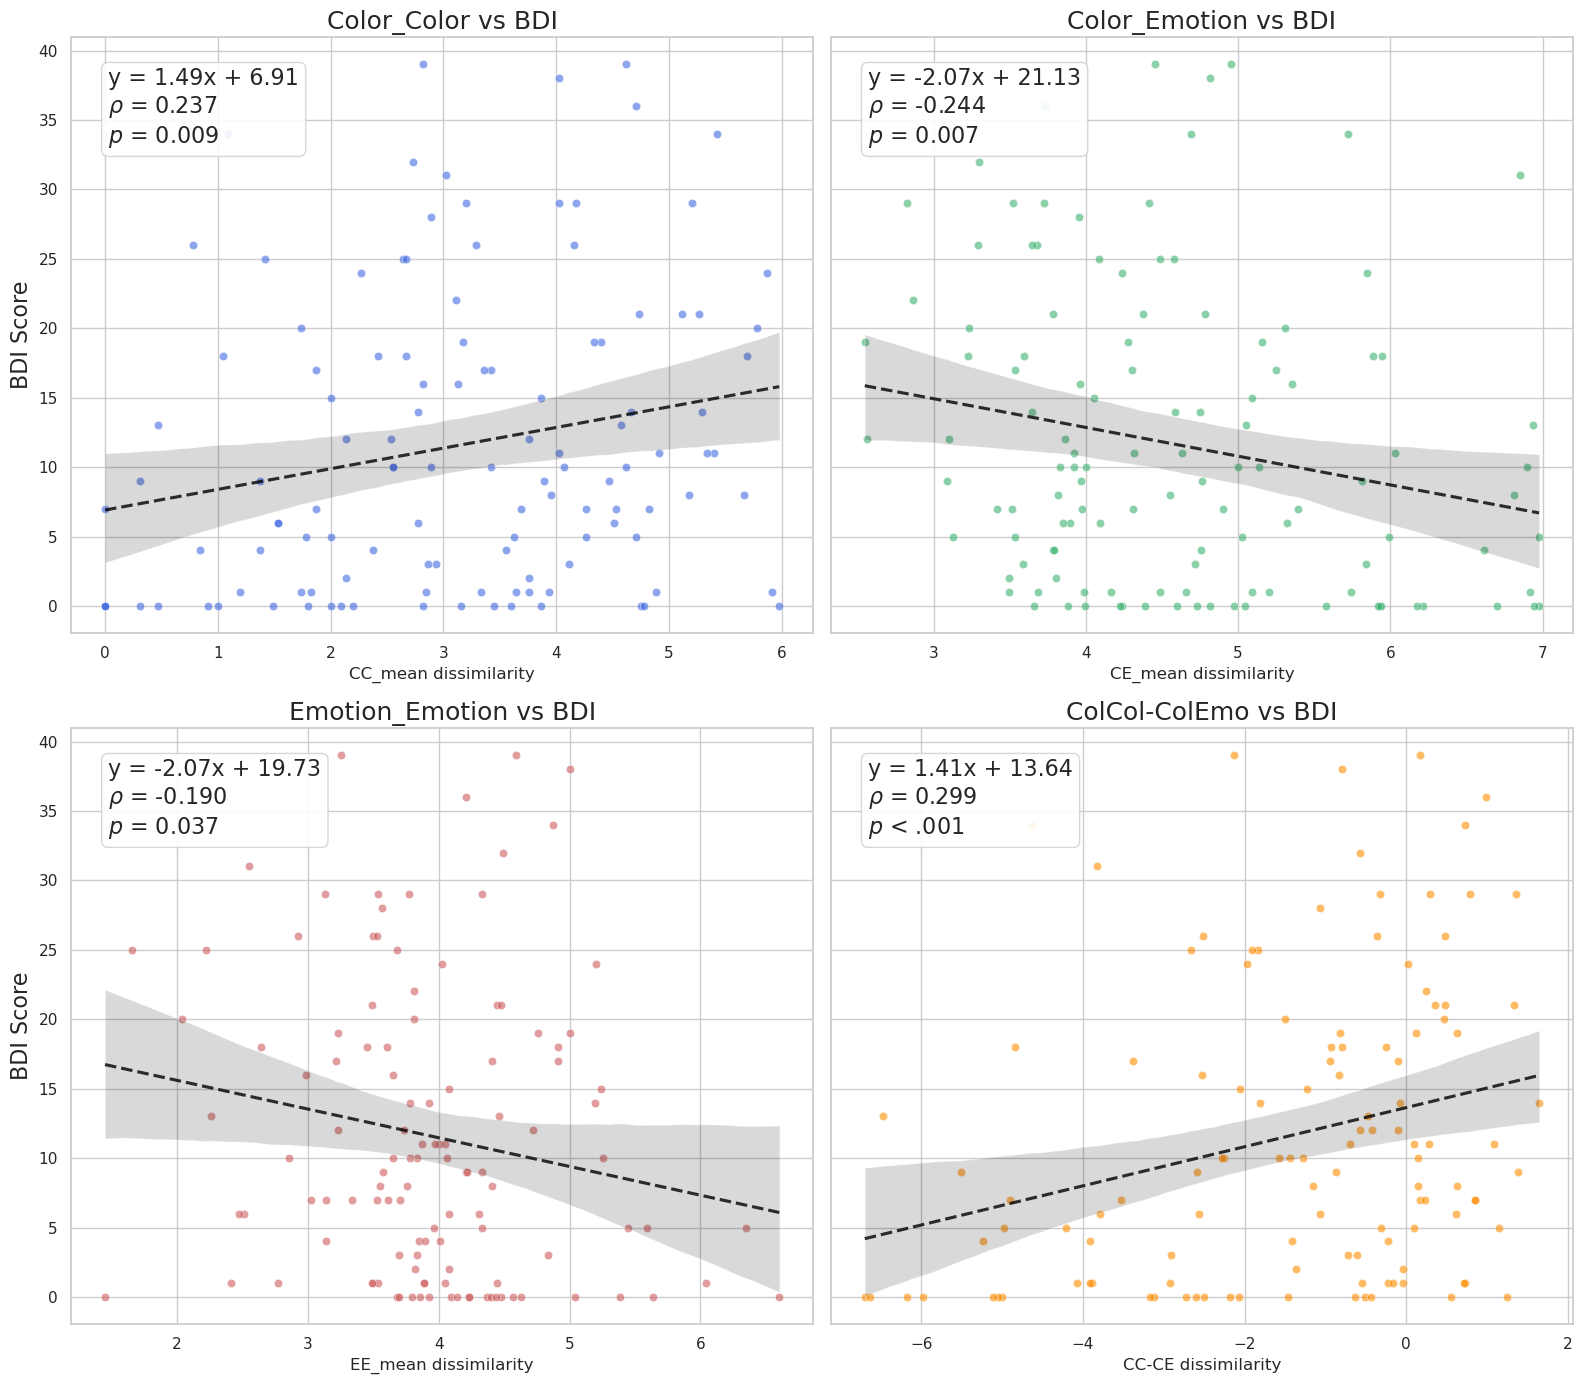

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# グラフのスタイル設定
sns.set_theme(style="whitegrid")

# 2x2のレイアウト作成
fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharey=True)
axes = axes.flatten() 

# 【修正】 cond_name を results_df の表記 (ColCol, ColEmo, EmoEmo, ColCol-ColEmo) に厳密に合わせました
plot_configs = [
    {'x_col': 'CC_mean', 'title': 'Color_Color vs BDI', 'color': 'royalblue', 'ax_idx': 0, 'cond_name': 'ColCol'},
    {'x_col': 'CE_mean', 'title': 'Color_Emotion vs BDI', 'color': 'mediumseagreen', 'ax_idx': 1, 'cond_name': 'ColEmo'},
    {'x_col': 'EE_mean', 'title': 'Emotion_Emotion vs BDI', 'color': 'indianred', 'ax_idx': 2, 'cond_name': 'EmoEmo'},
    {'x_col': 'CC-CE', 'title': 'ColCol-ColEmo vs BDI', 'color': 'darkorange', 'ax_idx': 3, 'cond_name': 'ColCol-ColEmo'}
]

for config in plot_configs:
    ax = axes[config['ax_idx']]
    x_col = config['x_col']
    
    # NaNを除外してデータを取得（回帰式の計算用）
    valid_data = df_merged[[x_col, 'BDI']].dropna()
    x_data = valid_data[x_col]
    y_data = valid_data['BDI']
    
    # 1. 回帰線の式 (y = ax + b) の傾きと切片を計算 (最小二乗法)
    slope, intercept, r_value, p_value_ols, std_err = stats.linregress(x_data, y_data)
    
    # 2. 相関係数とp値の取得
    # cond_name が完全に一致するようになったため、正常に値を取得できます
    row = results_df[results_df['Condition'] == config['cond_name']].iloc[0]
    rho = row['Spearman_rho']
    
    # 画像の列名に合わせる（p_val か p_value か確認して取得）
    p_col_name = 'p_val' if 'p_val' in results_df.columns else 'p_value'
    p_val = row[p_col_name]
        
    # グラフの描画
    sns.regplot(
        data=df_merged, 
        x=x_col, 
        y='BDI', 
        ax=ax, 
        color=config['color'],
        scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 'linewidths': 0.5}, 
        line_kws={'color': 'black', 'alpha': 0.8, 'linestyle': '--'}
    )
    
    # 3. 図中に書き込むテキストのフォーマット作成
    eq_text = f"y = {slope:.2f}x + {intercept:.2f}"
    
    # p値が非常に小さい場合の表記ルール (p < .001) を適用
    if p_val < 0.001:
        stat_text = f"$\\rho$ = {rho:.3f}\n$p$ < .001"
    else:
        stat_text = f"$\\rho$ = {rho:.3f}\n$p$ = {p_val:.3f}"
        
    # テキストをグラフ内の左上（X: 5%, Y: 95% の位置）に配置
    ax.text(0.05, 0.95, f"{eq_text}\n{stat_text}", 
            transform=ax.transAxes, 
            fontsize=16, verticalalignment='top', 
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor='lightgray'))
    
    # タイトルとX軸ラベル
    ax.set_title(config['title'], fontsize=18)
    ax.set_xlabel(f"{x_col} dissimilarity", fontsize=12)
    
    # Y軸ラベルの設定
    if config['ax_idx'] in [0, 2]:
        ax.set_ylabel('BDI Score', fontsize=16)
    else:
        ax.set_ylabel('')

plt.tight_layout()
plt.savefig("/home/jovyan/work/outputs/figs/corr_meandissim_bdi.png",dpi=300)
plt.show()